# MLR (Multiple Linear Regression)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Statsmodels
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
df = pd.read_csv("ToyotaCorolla - MLR.csv")

# View data
print(df.head())
print(df.info())

   Price  Age_08_04     KM Fuel_Type  HP  Automatic    cc  Doors  Cylinders  \
0  13500         23  46986    Diesel  90          0  2000      3          4   
1  13750         23  72937    Diesel  90          0  2000      3          4   
2  13950         24  41711    Diesel  90          0  2000      3          4   
3  14950         26  48000    Diesel  90          0  2000      3          4   
4  13750         30  38500    Diesel  90          0  2000      3          4   

   Gears  Weight  
0      5    1165  
1      5    1165  
2      5    1165  
3      5    1165  
4      5    1170  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null  

In [ ]:
# Rename columns
df.rename(columns={'Age_08_04': 'Age', 'Fuel_Type': 'FuelType'}, inplace=True)

# Convert categorical to numeric
df = pd.get_dummies(df, columns=['FuelType'], drop_first=True)

# Check missing values
print(df.isnull().sum())

# Drop missing if any
df.dropna(inplace=True)

Price              0
Age                0
KM                 0
HP                 0
Automatic          0
cc                 0
Doors              0
Cylinders          0
Gears              0
Weight             0
FuelType_Diesel    0
FuelType_Petrol    0
dtype: int64


# EDA

In [ ]:
print(df.describe())

              Price          Age             KM           HP    Automatic  \
count   1436.000000  1436.000000    1436.000000  1436.000000  1436.000000   
mean   10730.824513    55.947075   68533.259749   101.502089     0.055710   
std     3626.964585    18.599988   37506.448872    14.981080     0.229441   
min     4350.000000     1.000000       1.000000    69.000000     0.000000   
25%     8450.000000    44.000000   43000.000000    90.000000     0.000000   
50%     9900.000000    61.000000   63389.500000   110.000000     0.000000   
75%    11950.000000    70.000000   87020.750000   110.000000     0.000000   
max    32500.000000    80.000000  243000.000000   192.000000     1.000000   

                cc        Doors  Cylinders        Gears      Weight  
count   1436.00000  1436.000000     1436.0  1436.000000  1436.00000  
mean    1576.85585     4.033426        4.0     5.026462  1072.45961  
std      424.38677     0.952677        0.0     0.188510    52.64112  
min     1300.00000     2.0

## Correlation Matrix

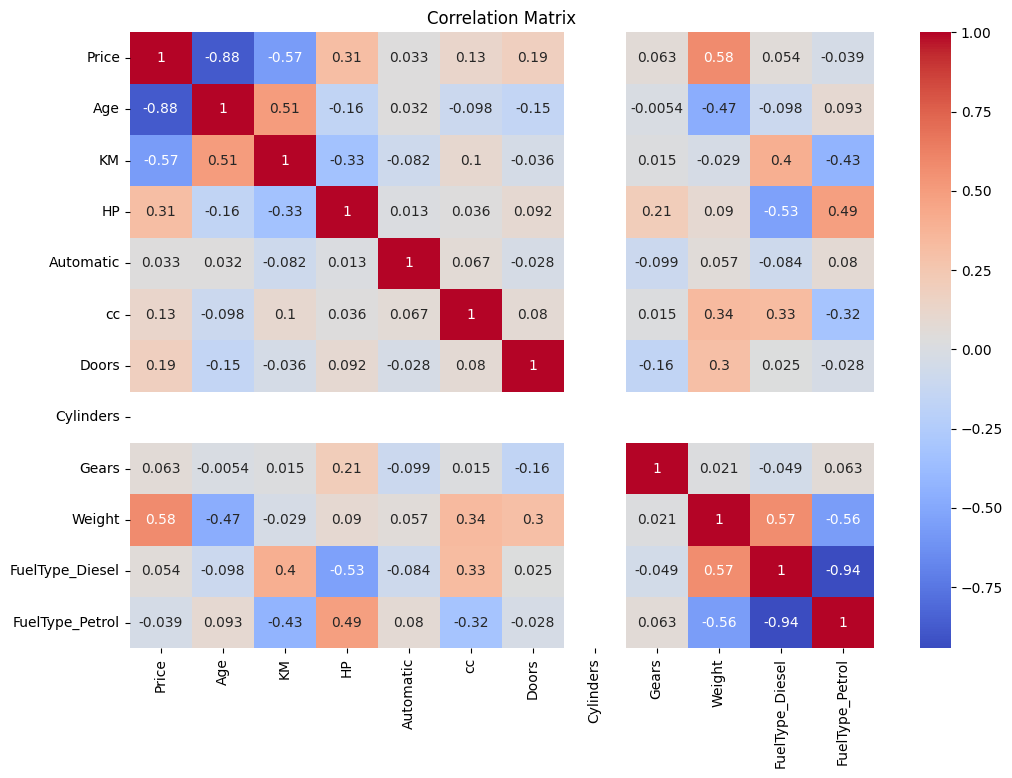

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## Distribution Plot

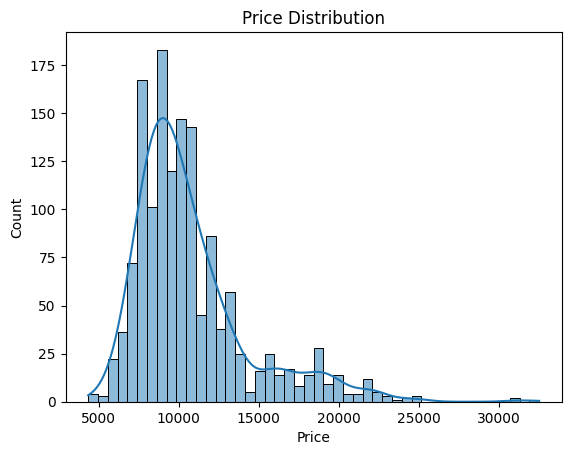

In [ ]:
sns.histplot(df['Price'], kde=True)
plt.title("Price Distribution")
plt.show()

## Scatter Plots

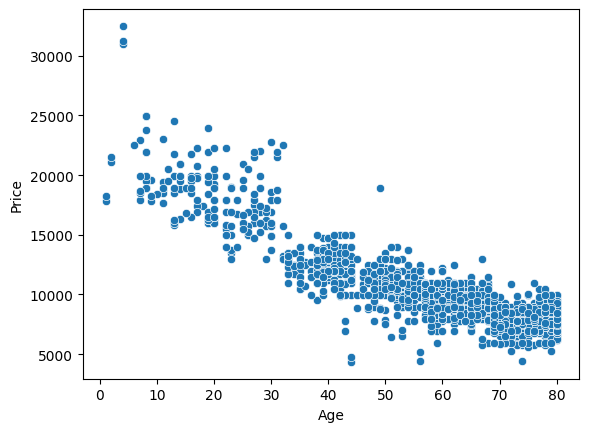

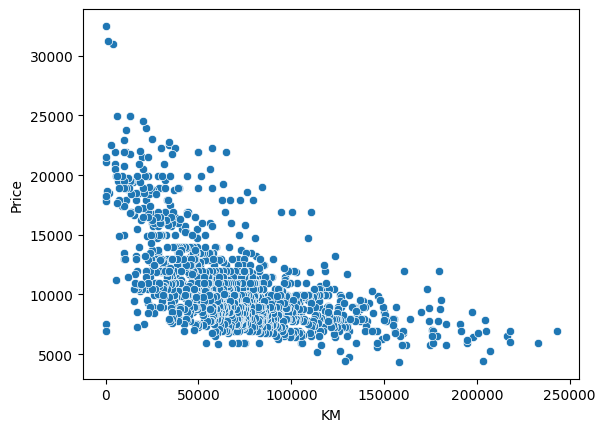

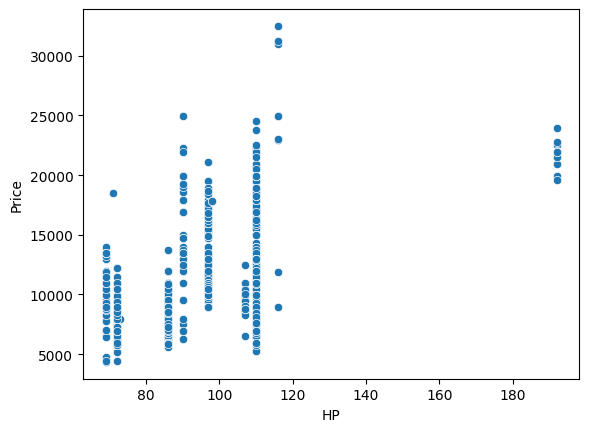

In [ ]:
sns.scatterplot(x='Age', y='Price', data=df)
plt.show()

sns.scatterplot(x='KM', y='Price', data=df)
plt.show()

sns.scatterplot(x='HP', y='Price', data=df)
plt.show()

# Define Features & Target

In [ ]:
X = df.drop('Price',axis=1)
y = df['Price']

# Multicollinearity Check

## VIF Calculation

In [ ]:
# Convert all columns to numeric (force errors to NaN)
X = X.apply(pd.to_numeric, errors='coerce')

In [ ]:
# Remove NaN and infinite values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()

In [ ]:
import statsmodels.api as sm

X_vif = sm.add_constant(X)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns

vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif_data)

            Feature          VIF
0               Age     1.920520
1                KM     2.001790
2                HP     2.299766
3         Automatic     1.094550
4                cc     1.223892
5             Doors     1.217898
6         Cylinders  1877.037630
7             Gears     1.117413
8            Weight     3.297145
9   FuelType_Diesel    11.317251
10  FuelType_Petrol     9.702194


In [ ]:

X_reduced = X.drop(['CC', 'Cylinders'], axis=1, errors='ignore')

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model 1 ; (Full Model)

In [ ]:
model1 = LinearRegression()
model1.fit(X_train_scaled, y_train)

y_pred1 = model1.predict(X_test_scaled)

print("MODEL 1 RESULTS")
print("R2:", r2_score(y_test, y_pred1))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred1)))

MODEL 1 RESULTS
R2: 0.8348888040611081
RMSE: 1484.265415329652


# Model 2 : (Reduced Features)

In [ ]:
# Drop weak features
X2 = X_reduced.drop(['Doors', 'Gears'], axis=1, errors='ignore')

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y, test_size=0.2, random_state=42
)

X_train2 = scaler.fit_transform(X_train2)
X_test2 = scaler.transform(X_test2)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)

print("\nMODEL 2 RESULTS")
print("R2:", r2_score(y_test2, y_pred2))


MODEL 2 RESULTS
R2: 0.8348487113704007


# Model 3 :(Important Features)

In [ ]:
X3 = df[['Age', 'KM', 'HP', 'Weight']]

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3, y, test_size=0.2, random_state=42
)

X_train3 = scaler.fit_transform(X_train3)
X_test3 = scaler.transform(X_test3)

model3 = LinearRegression()
model3.fit(X_train3, y_train3)

y_pred3 = model3.predict(X_test3)

print("\nMODEL 3 RESULTS")
print("R2:", r2_score(y_test3, y_pred3))


MODEL 3 RESULTS
R2: 0.8506068681500834


# Model Fit

In [ ]:
X_sm = sm.add_constant(X_reduced)
model_sm = sm.OLS(y, X_sm).fit()

print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.865
Model:                            OLS   Adj. R-squared:                  0.864
Method:                 Least Squares   F-statistic:                     912.3
Date:                Sat, 04 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:12:07   Log-Likelihood:                -12369.
No. Observations:                1436   AIC:                         2.476e+04
Df Residuals:                    1425   BIC:                         2.482e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const           -9861.0292   1529.450     

# Ridge Regression

In [ ]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

print("\nRIDGE RESULTS")
print("R2:", r2_score(y_test, y_pred_ridge))


RIDGE RESULTS
R2: 0.8350462635431574


# Lasso Regression

In [ ]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

print("\nLASSO RESULTS")
print("R2:", r2_score(y_test, y_pred_lasso))


LASSO RESULTS
R2: 0.8349116135580272


# Robust Regression

In [ ]:
robust_model = sm.RLM(y, X_sm).fit()

print("\nROBUST REGRESSION SUMMARY")
print(robust_model.summary())


ROBUST REGRESSION SUMMARY
                    Robust linear Model Regression Results                    
Dep. Variable:                  Price   No. Observations:                 1436
Model:                            RLM   Df Residuals:                     1425
Method:                          IRLS   Df Model:                           10
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Sat, 04 Apr 2026                                         
Time:                        20:14:34                                         
No. Iterations:                    14                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const          

# Checking Outliers

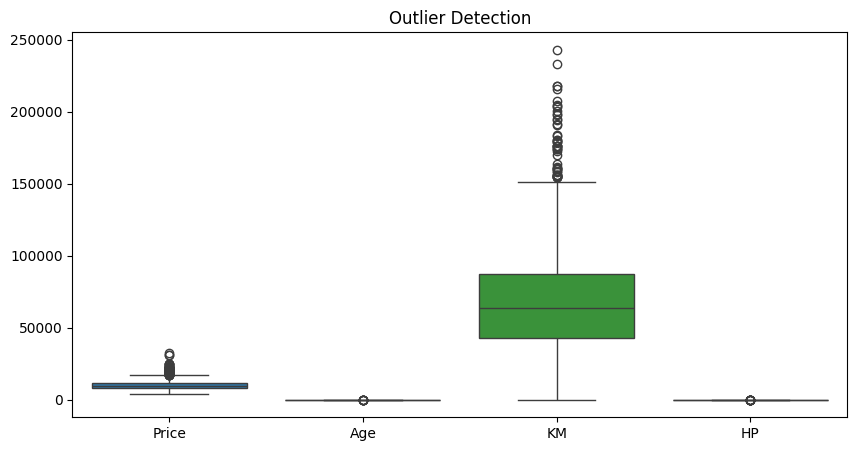

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['Price','Age','KM','HP']])
plt.title("Outlier Detection")
plt.show()

# Report

In [ ]:
""" Multicollinearity
.Used Correlation matrix & VIF
.Removed variables with high VIF
.Improve model stability"""

' Multicollinearity\n.Used Correlation matrix & VIF\n.Removed variables with high VIF \n.Improve model stability'

# Interview Questions

In [47]:
""" normalization vs standardization"""

' normalization vs standardization'

In [48]:
"""
normalization
. scales data btwn 0-1
.formula / code:
(x-min)/(max-min)

standardization
.mean = 0 ,std = 1
.formula/code :
(x-mean)/std
"""

'\nnormalization\n. scales data btwn 0-1\n.formula / code:\n(x-min)/(max-min)\n\nstandardization\n.mean = 0 ,std = 1\n.formula/code :\n(x-mean)/std\n'

In [49]:
"""2. Handling Multicollinearity"""

'2. Handling Multicollinearity'

In [50]:
"""
Techniques:
. Remove highly correlated viables
.use VIF(Variance Inflation Factor)
.Apply:
.Ridge Regression
.Lasso Regression
.Principal Component Analysis (PCA)
"""

'\nTechniques:\n. Remove highly correlated viables\n.use VIF(Variance Inflation Factor)\n.Apply:\n.Ridge Regression\n.Lasso Regression\n.Principal Component Analysis (PCA)\n'